# Analyse et Modélisation du Précipitations en Australie

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Charger le jeu de données
df = pd.read_csv('/content/weatherAUS.csv')

# Afficher les 5 premières lignes du DataFrame
print("Aperçu des données:")
display(df.head())

Aperçu des données:


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Afficher des informations générales sur le DataFrame
print("\nInformations sur les colonnes et types de données:")
df.info()


Informations sur les colonnes et types de données:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 

In [ ]:
# Vérifier les valeurs manquantes
print("\nPourcentage de valeurs manquantes par colonne:")
display(df.isnull().sum() / len(df) * 100)


Pourcentage de valeurs manquantes par colonne:


,0
Date,0.000000
Location,0.000000
MinTemp,1.020899
MaxTemp,0.866905
Rainfall,2.241853
Evaporation,43.166506
Sunshine,48.009762
WindGustDir,7.098859
WindGustSpeed,7.055548
WindDir9am,7.263853


## Exploration Visuelle des Données

Nous allons maintenant visualiser certaines caractéristiques clés pour mieux comprendre les données, en particulier la variable cible `RainTomorrow` (va-t-il pleuvoir demain).

/tmp/ipykernel_1096/1784179353.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='RainTomorrow', data=df, palette='viridis')


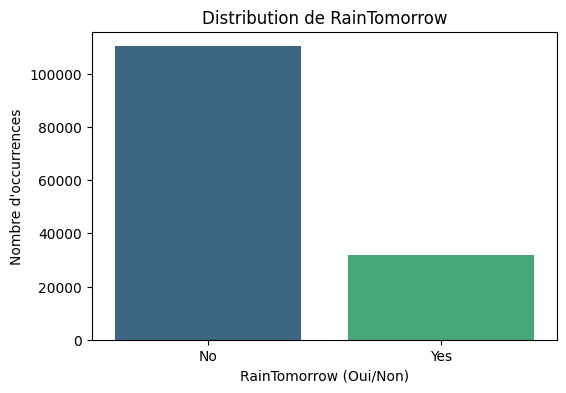

In [ ]:
# Distribution de la variable cible 'RainTomorrow'
plt.figure(figsize=(6, 4))
sns.countplot(x='RainTomorrow', data=df, palette='viridis')
plt.title('Distribution de RainTomorrow')
plt.xlabel('RainTomorrow (Oui/Non)')
plt.ylabel('Nombre d\'occurrences')
plt.show()

### Interprétation de la Distribution de RainTomorrow
Ce graphique montre la répartition des jours où il a plu le lendemain ('Oui') et où il n'a pas plu ('Non'). On observe un déséquilibre significatif, avec beaucoup plus de jours sans pluie que de jours avec pluie, ce qui indique une classe déséquilibrée pour la variable cible.

/tmp/ipykernel_1096/3368790119.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RainTomorrow', y='Temp3pm', data=df, ax=axes[0], palette='coolwarm')
/tmp/ipykernel_1096/3368790119.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RainTomorrow', y='Humidity3pm', data=df, ax=axes[1], palette='coolwarm')
/tmp/ipykernel_1096/3368790119.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RainTomorrow', y='WindSpeed9am', data=df, ax=axes[2], palette='coolwarm')


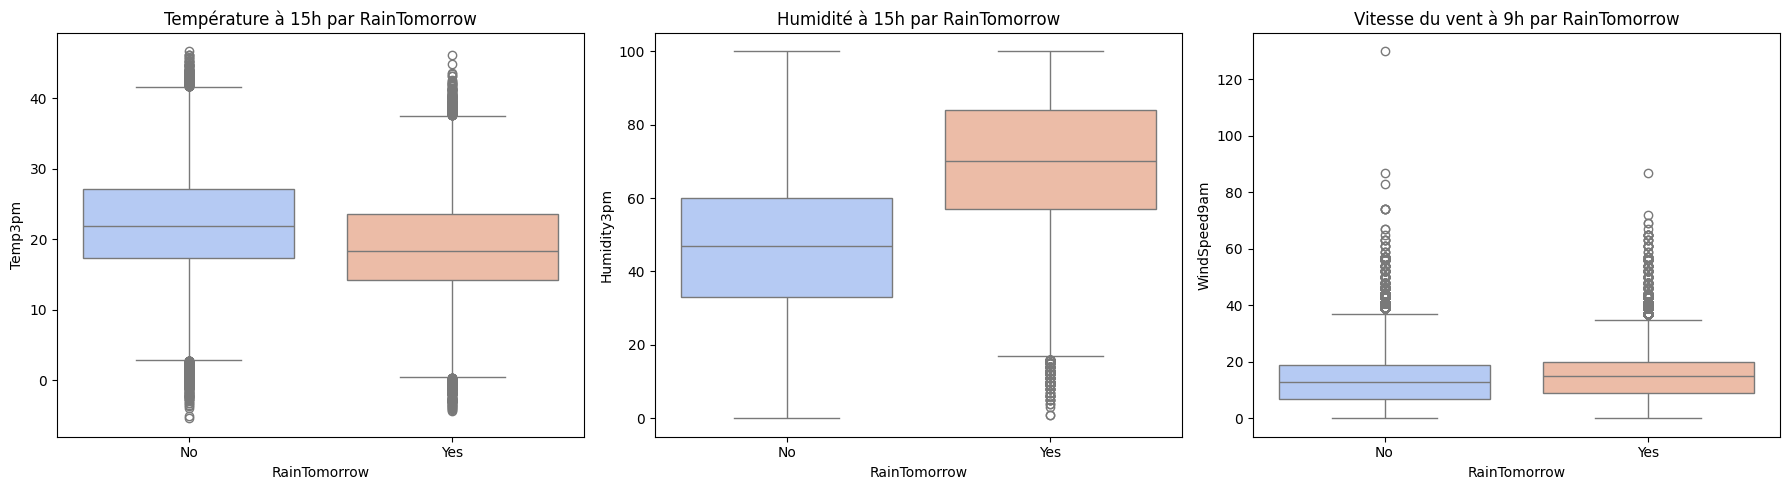

In [ ]:
# Visualisation des relations entre quelques variables numériques et RainTomorrow
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='RainTomorrow', y='Temp3pm', data=df, ax=axes[0], palette='coolwarm')
axes[0].set_title('Température à 15h par RainTomorrow')

sns.boxplot(x='RainTomorrow', y='Humidity3pm', data=df, ax=axes[1], palette='coolwarm')
axes[1].set_title('Humidité à 15h par RainTomorrow')

sns.boxplot(x='RainTomorrow', y='WindSpeed9am', data=df, ax=axes[2], palette='coolwarm')
axes[2].set_title('Vitesse du vent à 9h par RainTomorrow')

plt.tight_layout()
plt.show()

### Interprétation des Relations entre Variables Numériques et RainTomorrow
*   **Température à 15h par RainTomorrow**: La médiane de la température à 15h est légèrement plus basse les jours où il pleut le lendemain.
*   **Humidité à 15h par RainTomorrow**: L'humidité à 15h est nettement plus élevée les jours où il pleut le lendemain, ce qui est une corrélation forte et attendue.
*   **Vitesse du vent à 9h par RainTomorrow**: La vitesse du vent à 9h semble légèrement plus élevée les jours où il pleut le lendemain, bien que la différence soit moins prononcée que pour l'humidité.

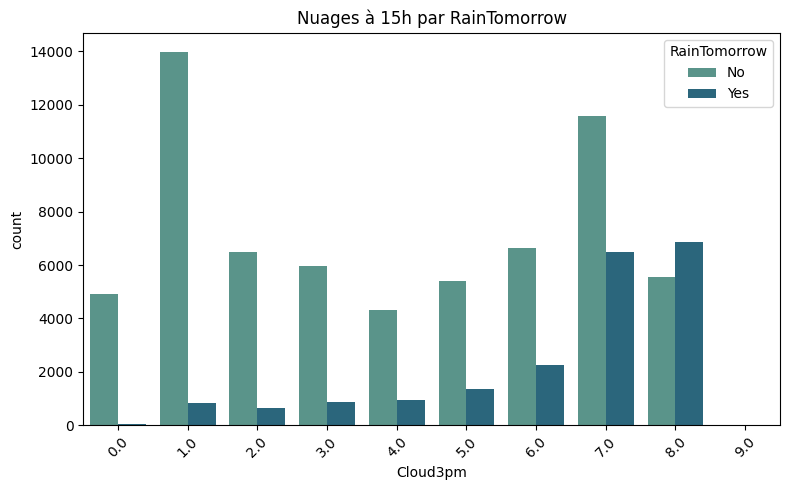

In [ ]:
# Visualisation des relations entre quelques variables catégoriques et RainTomorrow
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

sns.countplot(x='Cloud3pm', hue='RainTomorrow', data=df, ax=ax, palette='crest')
ax.set_title('Nuages à 15h par RainTomorrow')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Interprétation des Relations entre Variables Catégoriques et RainTomorrow
*   **Nuages à 15h par RainTomorrow**: Une couverture nuageuse plus importante à 15h (`Cloud3pm`) semble être associée à une probabilité plus élevée de pluie le lendemain, ce qui est logique.

## Préparation des Données pour la Modélisation

Avant de construire les modèles, nous devons nettoyer et préparer les données. Cela inclut la gestion des valeurs manquantes et l'encodage des variables catégoriques.

In [ ]:
# Suppression des colonnes avec trop de valeurs manquantes ou non pertinentes pour la prédiction directe
# 'Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm' ont un grand nombre de NaN
# 'Date' n'est pas directement utilisable sans feature engineering complexe pour ce code simple
df_processed = df.drop(columns=['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm', 'Date'], axis=1)

# Suppression des lignes où la variable cible 'RainTomorrow' est manquante
df_processed.dropna(subset=['RainTomorrow'], inplace=True)

# Imputation des valeurs manquantes pour les colonnes numériques avec la moyenne
for col in df_processed.select_dtypes(include=np.number).columns:
    if df_processed[col].isnull().any():
        df_processed[col].fillna(df_processed[col].mean(), inplace=True)

# Imputation des valeurs manquantes pour les colonnes catégoriques avec le mode
for col in df_processed.select_dtypes(include='object').columns:
    if df_processed[col].isnull().any():
        df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)

# Vérifier à nouveau les valeurs manquantes après imputation
print("\nPourcentage de valeurs manquantes après traitement:")
display(df_processed.isnull().sum() / len(df_processed) * 100)

# Encodage des variables catégoriques en utilisant One-Hot Encoding
df_encoded = pd.get_dummies(df_processed, drop_first=True)

# Afficher les 5 premières lignes du DataFrame après encodage
print("\nAperçu des données après encodage:")
display(df_encoded.head())

/tmp/ipykernel_1096/1216083121.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed[col].fillna(df_processed[col].mean(), inplace=True)
/tmp/ipykernel_1096/1216083121.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in


Pourcentage de valeurs manquantes après traitement:


,0
Location,0.0
MinTemp,0.0
MaxTemp,0.0
Rainfall,0.0
WindGustDir,0.0
WindGustSpeed,0.0
WindDir9am,0.0
WindDir3pm,0.0
WindSpeed9am,0.0
WindSpeed3pm,0.0



Aperçu des données après encodage:


,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,...,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,RainToday_Yes,RainTomorrow_Yes
0,13.4,22.9,0.6,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,...,False,False,False,False,False,False,True,False,False,False
1,7.4,25.1,0.0,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,...,False,False,False,False,False,False,False,True,False,False
2,12.9,25.7,0.0,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,...,False,False,False,False,False,False,False,True,False,False
3,9.2,28.0,0.0,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,...,False,False,False,False,False,False,False,False,False,False
4,17.5,32.3,1.0,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,...,False,False,False,False,False,False,False,False,False,False


## Modélisation du Rainfall

Nous allons utiliser deux algorithmes de classification fréquemment cités pour la prédiction binaire (va-t-il pleuvoir ou non) et reconnus pour leurs performances dans la littérature: la Régression Logistique et le Random Forest.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Définir les caractéristiques (X) et la variable cible (y)
X = df_encoded.drop('RainTomorrow_Yes', axis=1)
y = df_encoded['RainTomorrow_Yes']

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Taille de l'ensemble d'entraînement: {X_train.shape[0]} échantillons")
print(f"Taille de l'ensemble de test: {X_test.shape[0]} échantillons")

Taille de l'ensemble d'entraînement: 113754 échantillons
Taille de l'ensemble de test: 28439 échantillons


### Modèle 1: Régression Logistique

La Régression Logistique est un algorithme de classification simple mais efficace, souvent utilisé comme référence.


--- Évaluation du Modèle de Régression Logistique ---
Précision (Accuracy): 0.8448

Rapport de Classification:
               precision    recall  f1-score   support

       False       0.86      0.95      0.90     22064
        True       0.73      0.49      0.58      6375

    accuracy                           0.84     28439
   macro avg       0.80      0.72      0.74     28439
weighted avg       0.83      0.84      0.83     28439



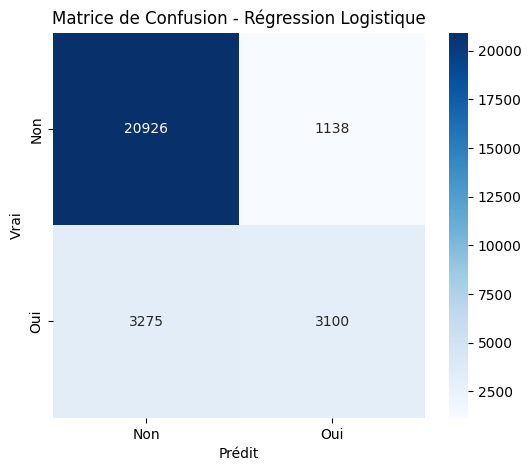

In [ ]:
# Initialiser et entraîner le modèle de Régression Logistique
log_reg_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
log_reg_model.fit(X_train, y_train)

# Faire des prédictions sur l'ensemble de test
y_pred_lr = log_reg_model.predict(X_test)

# Évaluer le modèle
print("\n--- Évaluation du Modèle de Régression Logistique ---")
print(f"Précision (Accuracy): {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nRapport de Classification:\n", classification_report(y_test, y_pred_lr))

# Matrice de confusion
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['Non', 'Oui'], yticklabels=['Non', 'Oui'])
plt.title('Matrice de Confusion - Régression Logistique')
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.show()

### Interprétation des Résultats du Modèle de Régression Logistique
*   **Précision (Accuracy)**: Le modèle a une précision d'environ 84.48%, ce qui est raisonnable. Cependant, l'accuracy seule peut être trompeuse avec des classes déséquilibrées.
*   **Rapport de Classification**: On observe une bonne **précision** pour la classe 'Non' (pas de pluie) mais une **sensibilité (recall)** plus faible pour la classe 'Oui' (pluie). Cela signifie que le modèle est bon pour prédire l'absence de pluie, mais il a du mal à identifier correctement tous les jours où il pleuvra (beaucoup de faux négatifs).
*   **Matrice de Confusion**: Elle confirme que le modèle prédit correctement l'absence de pluie dans la majorité des cas (20926 vrais négatifs) mais qu'il manque un nombre significatif de prédictions de pluie (3275 faux négatifs), tandis qu'il fait moins d'erreurs en prédisant la pluie alors qu'il ne pleut pas (1138 faux positifs).

### Modèle 2: Random Forest Classifier

Le Random Forest est un modèle d'ensemble puissant, réputé pour sa robustesse et sa capacité à gérer des données complexes et de nombreuses caractéristiques.


--- Évaluation du Modèle Random Forest ---
Précision (Accuracy): 0.8544

Rapport de Classification:
               precision    recall  f1-score   support

       False       0.87      0.96      0.91     22064
        True       0.78      0.49      0.60      6375

    accuracy                           0.85     28439
   macro avg       0.82      0.73      0.76     28439
weighted avg       0.85      0.85      0.84     28439



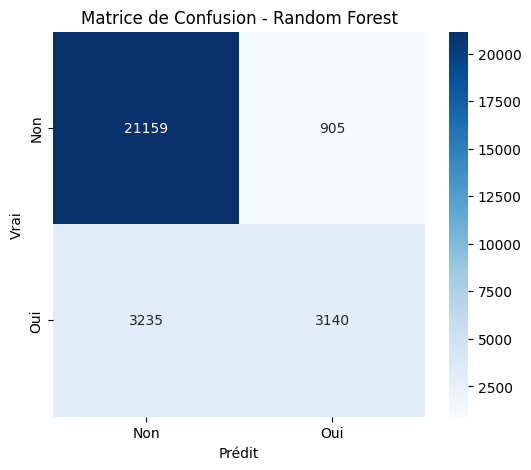

In [ ]:
# Initialiser et entraîner le modèle Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Faire des prédictions sur l'ensemble de test
y_pred_rf = rf_model.predict(X_test)

# Évaluer le modèle
print("\n--- Évaluation du Modèle Random Forest ---")
print(f"Précision (Accuracy): {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nRapport de Classification:\n", classification_report(y_test, y_pred_rf))

# Matrice de confusion
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Non', 'Oui'], yticklabels=['Non', 'Oui'])
plt.title('Matrice de Confusion - Random Forest')
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.show()

### Interprétation des Résultats du Modèle Random Forest
*   **Précision (Accuracy)**: Le modèle Random Forest atteint une précision d'environ 85.44%, légèrement supérieure à celle de la Régression Logistique.
*   **Rapport de Classification**: Similaire à la Régression Logistique, le modèle a une excellente précision et rappel pour la classe 'Non'. Pour la classe 'Oui', la précision est meilleure (0.78 vs 0.73) et le rappel est légèrement meilleur (0.49 vs 0.49), ce qui indique une légère amélioration dans la détection des événements de pluie.
*   **Matrice de Confusion**: Le Random Forest montre une légère amélioration par rapport à la Régression Logistique, avec un peu plus de vrais positifs (3140 vs 3100) et un peu moins de faux positifs (905 vs 1138), et un nombre légèrement réduit de faux négatifs (3235 vs 3275).